## 1. Execute the initial notebook workspace cells to install required data libraries (pandas, numpy, matplotlib, seaborn, scikit-learn).

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

## 2. Upload the custom country metrics CSV dataset into the active Colab environment.

In [2]:
import pandas as pd
df = pd.read_csv("/content/Country-data.csv")

## 3. Execute the data cleaning chain: strip whitespace from column titles, drop duplicate records, force numeric types, and impute missing values using median features.

In [3]:
#strip whitespace from column titles
df.columns = df.columns.str.strip()

# drop duplicate records
df = df.drop_duplicates()

#force numeric types
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#impute missing values using median features
for col in df.columns[1:]:
    df[col] = df[col].fillna(df[col].median())

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


## 4. Strip the country name identifier string to isolate continuous features and scale all rows using StandardScaler.


In [4]:
df_new=df.copy()

In [5]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[ 1.29153238 -1.13827979  0.27908825 ... -1.61909203  1.90288227
  -0.67917961]
 [-0.5389489  -0.47965843 -0.09701618 ...  0.64786643 -0.85997281
  -0.48562324]
 [-0.27283273 -0.09912164 -0.96607302 ...  0.67042323 -0.0384044
  -0.46537561]
 ...
 [-0.37231541  1.13030491  0.0088773  ...  0.28695762 -0.66120626
  -0.63775406]
 [ 0.44841668 -0.40647827 -0.59727159 ... -0.34463279  1.14094382
  -0.63775406]
 [ 1.11495062 -0.15034774 -0.33801514 ... -2.09278484  1.6246091
  -0.62954556]]


## 5. Run an optimization loop testing cluster ranges kâˆˆ[2,10], save inertia values, and chart the curve in an Elbow Method line plot.

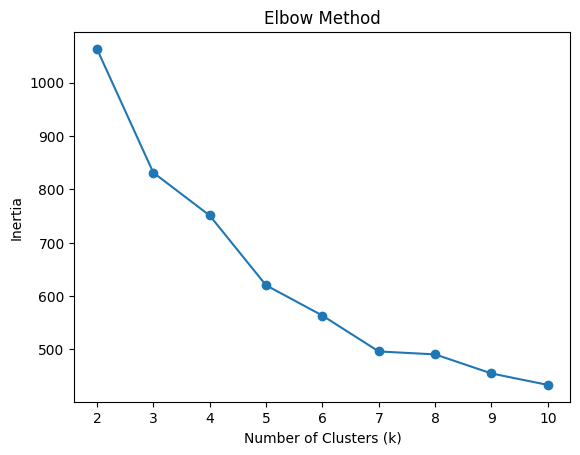

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 6. Define the baseline cluster count (best_k = 3) and train your K-Means model.


In [12]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(clusters[:10])

[2 0 0 2 0 0 0 1 1 0]


## 7. Evaluate clustering performance by printing the silhouette_score.


In [13]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.30088229124112015


## 8. Build a secondary comparative clustering model using DBSCAN (eps=1.5, min_samples=5).


In [14]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
print(db_labels)

[ 0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0  0  0  0  0  0 -1  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0
 -1 -1  0  0  0  0  0  0  0 -1 -1  0  0  0  0 -1 -1  0  0 -1  0  0  0  0
  0  0 -1  0  0 -1  0 -1  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0
  0  0  0 -1  0  0 -1  0  0  0  0 -1 -1 -1  0  0  0 -1  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0 -1  0  0  0]


## 9. Project high-dimensional records into 2D using PCA and map K-Means classifications to a color-coded scatterplot.

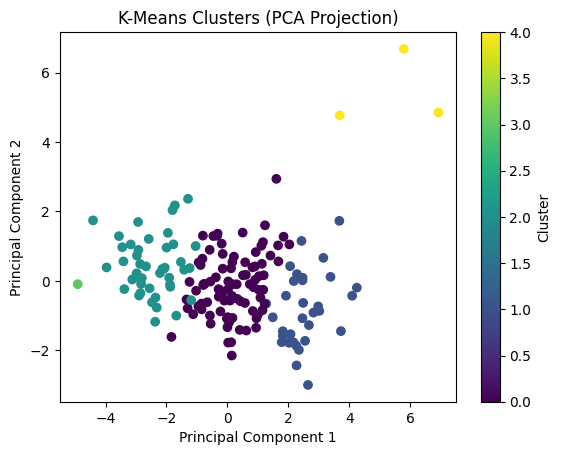

In [15]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()

## Write 3 to 5 observations about the clusters:


In [17]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.219540,41.083782,6.246667,47.795010,12678.965517,7.727747,72.625287,2.333333,6494.390805
1,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
2,94.313636,28.677500,6.329091,42.872727,3503.250000,9.895568,59.022727,5.047727,1753.909091
3,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000
4,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


## Final Insights

### 1. Which cluster has the highest child mortality?
- Cluster 3 has the highest child mortality rate (130).
- It also has a low life expectancy (60.5 years), indicating poor healthcare and living conditions.
- This cluster represents the most socially and economically vulnerable countries.

### 2. Which cluster has the highest income and GDP per capita?
- Cluster 4 has the highest average income (64033.33) and GDP per capita (57566.67).
- It also has the lowest child mortality rate (4.13) and the highest life expectancy (81.43 years).
- This cluster represents highly developed and economically strong countries.

### 3. Which cluster looks underdeveloped?
- Cluster 3 appears to be the most underdeveloped cluster.
- It is characterized by high child mortality, low income, low GDP per capita, and low life expectancy.
- The cluster also has extremely high inflation, indicating economic instability.

### 4. Countries to Prioritize for Aid
- Countries belonging to Cluster 3 should be given the highest priority for aid.
- These countries face severe economic and health-related challenges.
- International assistance in healthcare, education, and infrastructure can help improve their development indicators.